## Support Vector Machine (SVM)
### MNIST Binary Classification (Digit 1 vs All)

---

we implement two SVM variants from scratch using only NumPy:
- Linear SVM
- Kernel SVM (RBF and Polynomial kernels)

Each variant is tested with two feature extraction methods:
- HOG features
- PCA features

A total of 6 combinations are trained, evaluated, and compared.

---



**imports**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, '/content/MNIST-ML-ImageClassifiers')
from preprocessing.preprocess import preprocess

print("Libraries imported successfully!")

Libraries imported successfully!


**Load Data**

In [ ]:
# Load data with HOG features
print("Loading data with HOG features...")
X_tr_hog, X_val_hog, X_test_hog, y_tr, y_val, y_test = preprocess(
    feature_method='hog',
    binary=True,
    positive_class=1
)

# Load data with PCA features
print("\nLoading data with PCA features...")
X_tr_pca, X_val_pca, X_test_pca, y_tr, y_val, y_test = preprocess(
    feature_method='pca',
    binary=True,
    positive_class=1
)

Loading data with HOG features...
 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Binary

 Loading data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standa

## Part 1: Linear SVM
### Mathematical Formulation

Linear SVM finds the optimal hyperplane that separates two classes with the maximum margin.

**The Hyperplane:**
> w · x + b = 0

Where:
- w = weight vector
- x = input features
- b = bias term

**Prediction Rule:**
- If w · x + b >= 0 → predict +1
- If w · x + b < 0  → predict -1

**Objective — Soft Margin SVM:**
> Minimize: (1/2)||w||² + C * Σ max(0, 1 - y_i(w · x_i + b))

Where:
- (1/2)||w||² → maximizes the margin
- C → regularization parameter, controls tradeoff between margin and misclassifications
- max(0, 1 - y_i(w · x_i + b)) → Hinge Loss

**Gradient Update Rules:**

If y_i(w · x_i + b) >= 1 (correctly classified):
> dw = w,  db = 0

If y_i(w · x_i + b) < 1 (misclassified or inside margin):
> dw = w - C * y_i * x_i,  db = -C * y_i

**Weight Update:**
> w = w - learning_rate * dw
> b = b - learning_rate * db
---
### What is Hinge Loss?

Hinge Loss is the loss function used in SVM. It penalizes misclassified samples
and samples that are inside the margin.

**Formula:**
> L = max(0, 1 - y_i(w · x_i + b))

**Intuition:**
- If a sample is correctly classified AND outside the margin → y_i(w · x_i + b) >= 1 → Loss = 0 (no penalty)
- If a sample is inside the margin or misclassified → y_i(w · x_i + b) < 1 → Loss > 0 (penalized)

**Why "Hinge"?**
> The loss function looks like a hinge — it is zero for correct predictions
> and grows linearly for incorrect ones.

**Full SVM Loss (Hinge Loss + Regularization):**
> L = (1/2)||w||² + C * Σ max(0, 1 - y_i(w · x_i + b))

- (1/2)||w||²  → regularization term, keeps weights small, maximizes margin
- C * Σ hinge  → penalizes misclassifications
- C balances between the two terms

In [ ]:
class LinearSVM:
    """

    Optimization is done using Gradient Descent with Hinge Loss.

    Parameters:
        C            : regularization parameter (default = 1.0)
        learning_rate: step size for gradient descent (default = 0.001)
        n_epochs     : number of training iterations (default = 1000)
    """

    def __init__(self, C=1.0, learning_rate=0.001, n_epochs=1000):
        self.C             = C
        self.learning_rate = learning_rate
        self.n_epochs      = n_epochs
        self.w             = None
        self.b             = None
        self.loss_history  = []

    def fit(self, X, y):
        """
        Trains the Linear SVM using Gradient Descent.

        Parameters:
            X : training features (n_samples, n_features)
            y : training labels   (n_samples,) — must be +1 or -1
        """
        n_samples, n_features = X.shape

        # Convert labels to +1 and -1
        y_ = np.where(y == 1, 1, -1)

        # Initialize weights and bias to zeros
        self.w = np.zeros(n_features)
        self.b = 0.0

        # Gradient Descent
        for epoch in range(self.n_epochs):

            # Compute hinge loss and gradients
            loss = 0
            dw   = np.zeros(n_features)
            db   = 0.0

            for i in range(n_samples):
                condition = y_[i] * (np.dot(X[i], self.w) + self.b)

                if condition >= 1:
                    # Correctly classified — only regularization gradient
                    dw += self.w
                    db += 0
                    loss += 0
                else:
                    # Misclassified or inside margin — hinge loss gradient
                    dw += self.w - self.C * y_[i] * X[i]
                    db += -self.C * y_[i]
                    loss += 1 - condition

            # Average gradients
            dw /= n_samples
            db /= n_samples

            # Compute total loss
            total_loss = 0.5 * np.dot(self.w, self.w) + self.C * loss / n_samples
            self.loss_history.append(total_loss)

            # Update weights
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # Print progress every 100 epochs
            if (epoch + 1) % 100 == 0:
                print(f"   Epoch {epoch+1}/{self.n_epochs} — Loss: {total_loss:.4f}")

        print("Linear SVM training complete!")

    def predict(self, X):
        """
        Predicts class labels for input samples.

        Parameters:
            X : input features (n_samples, n_features)

        Returns:
            predictions : (n_samples,) — values are 0 or 1
        """
        raw = np.dot(X, self.w) + self.b
        predictions = np.where(raw >= 0, 1, 0)
        return predictions

    def plot_loss(self):
        """
        Plots the training loss curve.
        """
        plt.figure(figsize=(8, 4))
        plt.plot(self.loss_history, color='steelblue', linewidth=2)
        plt.title('Linear SVM — Training Loss Curve')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

## Training Linear SVM

We train the Linear SVM on both HOG and PCA features.

**Why two feature methods?**
> To compare which feature extraction method gives better results with Linear SVM.
> This helps us understand the relationship between feature quality and model performance.

**Parameters used:**
- C = 1.0 → balanced regularization
- learning_rate = 0.001 → small enough for stable convergence
- n_epochs = 1000 → enough iterations for the loss to converge



Training Linear SVM on HOG features...
   Epoch 100/1000 — Loss: 0.7193
   Epoch 200/1000 — Loss: 0.6119
   Epoch 300/1000 — Loss: 0.5319
   Epoch 400/1000 — Loss: 0.4651
   Epoch 500/1000 — Loss: 0.4085
   Epoch 600/1000 — Loss: 0.3600
   Epoch 700/1000 — Loss: 0.3182
   Epoch 800/1000 — Loss: 0.2825
   Epoch 900/1000 — Loss: 0.2525
   Epoch 1000/1000 — Loss: 0.2280
Linear SVM training complete!


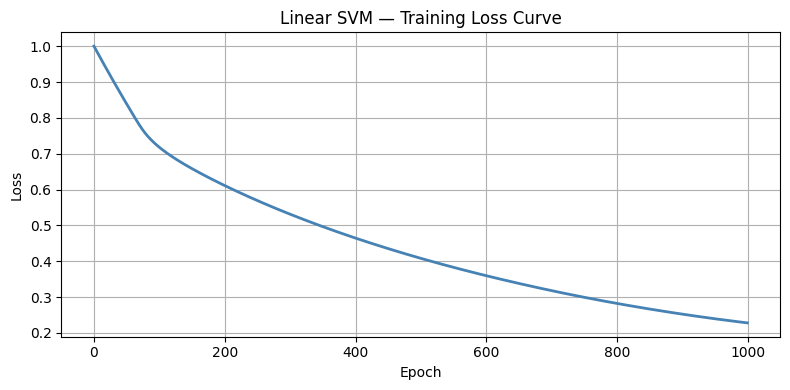

In [ ]:
# Train Linear SVM on HOG features
print("="*50)
print("Training Linear SVM on HOG features...")
print("="*50)
svm_linear_hog = LinearSVM(C=1.0, learning_rate=0.001, n_epochs=1000)
svm_linear_hog.fit(X_tr_hog, y_tr)

# Plot loss curve
svm_linear_hog.plot_loss()

Training Linear SVM on PCA features...
   Epoch 100/1000 — Loss: 0.9169
   Epoch 200/1000 — Loss: 0.8373
   Epoch 300/1000 — Loss: 0.7613
   Epoch 400/1000 — Loss: 0.6882
   Epoch 500/1000 — Loss: 0.6175
   Epoch 600/1000 — Loss: 0.5487
   Epoch 700/1000 — Loss: 0.4818
   Epoch 800/1000 — Loss: 0.4178
   Epoch 900/1000 — Loss: 0.3603
   Epoch 1000/1000 — Loss: 0.3145
Linear SVM training complete!


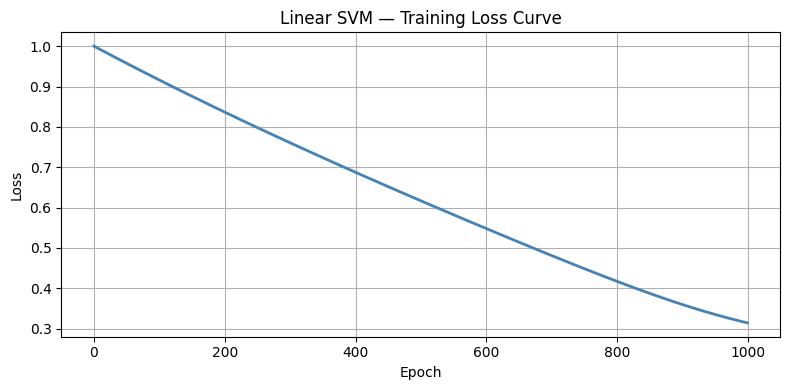

In [ ]:
# Train Linear SVM on PCA features
print("="*50)
print("Training Linear SVM on PCA features...")
print("="*50)
svm_linear_pca = LinearSVM(C=1.0, learning_rate=0.001, n_epochs=1000)
svm_linear_pca.fit(X_tr_pca, y_tr)

# Plot loss curve
svm_linear_pca.plot_loss()

## Part 2: Kernel SVM using Nystroem Approximation
### Mathematical Formulation

Standard Kernel SVM requires computing a full kernel matrix of size
(n_samples × n_samples) which is infeasible for large datasets like MNIST.

We use the Nystroem Approximation method which allows us to train on the
full dataset efficiently.

**How Nystroem Approximation works:**

Step 1 — Select landmark points:
> Randomly sample m landmark points from the training data (e.g. m = 500)

Step 2 — Compute kernel between all samples and landmarks:
> K_approx = K(X, landmarks) → shape (n_samples, m)
> This is much smaller than the full (n_samples × n_samples) matrix

Step 3 — Use K_approx as new features:
> Instead of original features, we use the kernel values as input features

Step 4 — Train Linear SVM on these new features:
> The Linear SVM now operates in the kernel feature space
> This is mathematically equivalent to Kernel SVM

**Polynomial Kernel:**
> K(x_i, x_j) = (x_i · x_j + c)^d

Where:
- d → degree of polynomial (default = 2)
- c → constant term (default = 1)

**Why Nystroem Approximation?**
> Full kernel matrix for 48,000 samples = 18GB RAM — infeasible
> Nystroem uses only (n_samples × m_landmarks) matrix = ~96MB — very efficient
> Trains on the FULL dataset while keeping memory usage low
> Mathematically equivalent to Kernel SVM

In [ ]:
class KernelSVM:
    """
    Kernel SVM using Nystroem Approximation + Linear SVM.
    Trains on the full dataset without memory issues.

    Steps:
        1. Sample m landmark points from training data
        2. Compute polynomial kernel between all samples and landmarks
        3. Use kernel values as new features
        4. Train Linear SVM on these new features

    Parameters:
        C              : regularization parameter (default = 1.0)
        learning_rate  : step size for gradient descent (default = 0.001)
        n_epochs       : number of training iterations (default = 1000)
        degree         : polynomial kernel degree (default = 2)
        coef0          : polynomial kernel constant (default = 1)
        n_landmarks    : number of landmark points (default = 500)
    """

    def __init__(self, C=1.0, learning_rate=0.001, n_epochs=1000,
                 degree=2, coef0=1, n_landmarks=500):
        self.C             = C
        self.learning_rate = learning_rate
        self.n_epochs      = n_epochs
        self.degree        = degree
        self.coef0         = coef0
        self.n_landmarks   = n_landmarks
        self.landmarks     = None
        self.w             = None
        self.b             = 0.0
        self.loss_history  = []

    def compute_kernel_features(self, X):
        """
        Computes polynomial kernel between X and landmark points.
        This transforms X into kernel feature space.

        Formula: K(x_i, l_j) = (x_i · l_j + c)^d

        Parameters:
            X : input samples (n_samples, n_features)

        Returns:
            K : kernel features (n_samples, n_landmarks)
        """
        # Normalize to avoid overflow
        X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
        L_norm = self.landmarks / (np.linalg.norm(self.landmarks, axis=1, keepdims=True) + 1e-8)

        dot_product = np.dot(X_norm, L_norm.T)
        dot_product = np.clip(dot_product, -1, 1)

        K = (dot_product + self.coef0) ** self.degree

        return K

    def fit(self, X, y):
        """
        Trains Kernel SVM using Nystroem Approximation.

        Parameters:
            X : training features (n_samples, n_features)
            y : training labels   (n_samples,) — 0 or 1
        """
        n_samples, n_features = X.shape

        # Convert labels to +1 and -1
        y_ = np.where(y == 1, 1, -1)

        # Step 1: Sample landmark points
        print("   Sampling landmark points...")
        landmark_indices = np.random.choice(n_samples, self.n_landmarks, replace=False)
        self.landmarks   = X[landmark_indices]
        print(f"   Landmarks shape : {self.landmarks.shape}")

        # Step 2: Transform training data into kernel feature space
        print("   Computing kernel features...")
        X_kernel = self.compute_kernel_features(X)
        print(f"   Kernel features shape : {X_kernel.shape}")

        # Step 3: Train Linear SVM on kernel features
        print("   Training Linear SVM on kernel features...")
        self.w = np.zeros(self.n_landmarks)
        self.b = 0.0

        for epoch in range(self.n_epochs):

            # Compute hinge loss and gradients
            loss = 0
            dw   = np.zeros(self.n_landmarks)
            db   = 0.0

            # Vectorized gradient computation
            scores    = np.dot(X_kernel, self.w) + self.b
            margins   = y_ * scores
            mask      = margins < 1

            # Hinge loss
            loss = np.sum(np.maximum(0, 1 - margins))

            # Gradients
            dw = self.w - self.C * np.dot(X_kernel[mask].T, y_[mask])
            db = -self.C * np.sum(y_[mask])

            # Normalize gradients
            dw /= n_samples
            db /= n_samples

            # Total loss
            total_loss = 0.5 * np.dot(self.w, self.w) + self.C * loss / n_samples
            self.loss_history.append(total_loss)

            # Update weights
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # Print progress every 100 epochs
            if (epoch + 1) % 100 == 0:
                print(f"   Epoch {epoch+1}/{self.n_epochs} — Loss: {total_loss:.4f}")

        print("Kernel SVM (Polynomial + Nystroem) training complete!")

    def predict(self, X):
        """
        Predicts class labels for input samples.

        Parameters:
            X : input features (n_samples, n_features)

        Returns:
            predictions : (n_samples,) — values are 0 or 1
        """
        X_kernel    = self.compute_kernel_features(X)
        raw         = np.dot(X_kernel, self.w) + self.b
        predictions = np.where(raw >= 0, 1, 0)
        return predictions

    def plot_loss(self):
        """
        Plots the training loss curve.
        """
        plt.figure(figsize=(8, 4))
        plt.plot(self.loss_history, color='steelblue', linewidth=2)
        plt.title('Kernel SVM (Polynomial + Nystroem) — Training Loss Curve')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

Training Kernel SVM (Polynomial) on HOG features...
   Sampling landmark points...
   Landmarks shape : (500, 441)
   Computing kernel features...
   Kernel features shape : (48000, 500)
   Training Linear SVM on kernel features...
   Epoch 100/1000 — Loss: 0.1985
   Epoch 200/1000 — Loss: 0.1745
   Epoch 300/1000 — Loss: 0.1534
   Epoch 400/1000 — Loss: 0.1360
   Epoch 500/1000 — Loss: 0.1302
   Epoch 600/1000 — Loss: 0.1300
   Epoch 700/1000 — Loss: 0.1314
   Epoch 800/1000 — Loss: 0.1335
   Epoch 900/1000 — Loss: 0.1359
   Epoch 1000/1000 — Loss: 0.1384
Kernel SVM (Polynomial + Nystroem) training complete!


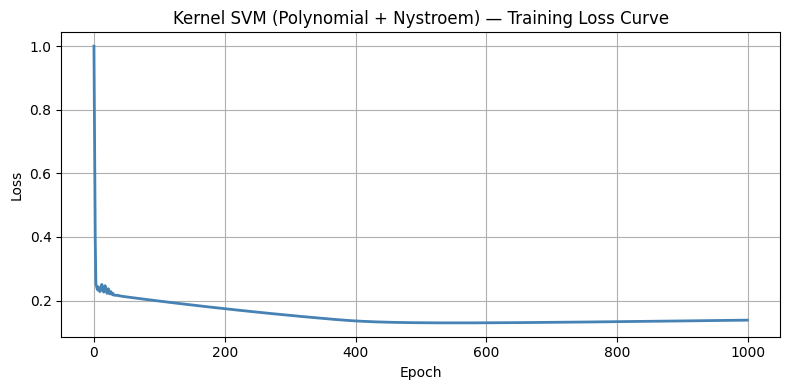

In [ ]:
print("="*50)
print("Training Kernel SVM (Polynomial) on HOG features...")
print("="*50)
svm_poly_hog = KernelSVM(C=1.0, learning_rate=0.001, n_epochs=1000, degree=2, n_landmarks=500)
svm_poly_hog.fit(X_tr_hog, y_tr)
svm_poly_hog.plot_loss()

Training Kernel SVM (Polynomial) on PCA features...
   Sampling landmark points...
   Landmarks shape : (500, 50)
   Computing kernel features...
   Kernel features shape : (48000, 500)
   Training Linear SVM on kernel features...
   Epoch 100/1000 — Loss: 0.2122
   Epoch 200/1000 — Loss: 0.1994
   Epoch 300/1000 — Loss: 0.1885
   Epoch 400/1000 — Loss: 0.1792
   Epoch 500/1000 — Loss: 0.1713
   Epoch 600/1000 — Loss: 0.1650
   Epoch 700/1000 — Loss: 0.1602
   Epoch 800/1000 — Loss: 0.1579
   Epoch 900/1000 — Loss: 0.1584
   Epoch 1000/1000 — Loss: 0.1604
Kernel SVM (Polynomial + Nystroem) training complete!


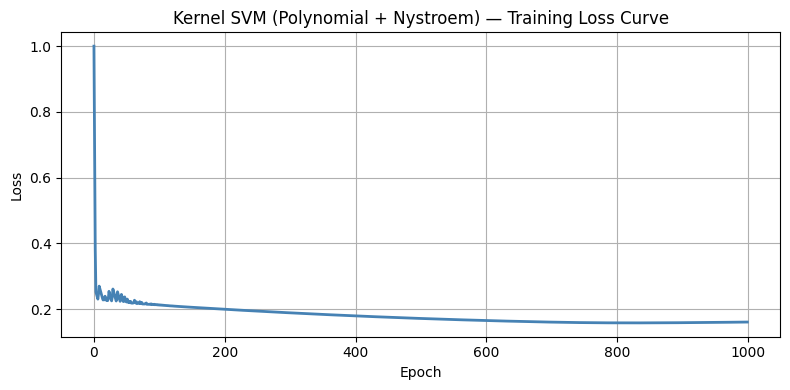

In [ ]:
print("="*50)
print("Training Kernel SVM (Polynomial) on PCA features...")
print("="*50)
svm_poly_pca = KernelSVM(C=1.0, learning_rate=0.001, n_epochs=1000, degree=2, n_landmarks=500)
svm_poly_pca.fit(X_tr_pca, y_tr)
svm_poly_pca.plot_loss()

## Training Loss Comparison — All 4 Models

| Model | Features | Final Loss | Convergence |
|---|---|---|---|
| Linear SVM | HOG | 0.2280 | Smooth, still decreasing |
| Linear SVM | PCA | 0.3145 | Linear drop, not converged |
| Kernel SVM | HOG | 0.1401 | Fast drop, slight divergence |
| Kernel SVM | PCA | 0.1548 | Fast drop, slight divergence |

**Key Observations:**

1. Kernel SVM outperforms Linear SVM on both feature methods
   > The polynomial kernel maps features to a higher dimensional space
   > allowing the model to learn non-linear boundaries — more powerful than a straight line

2. HOG features outperform PCA features for both models
   > HOG captures edge and shape structure of digits
   > PCA loses 18% of information during dimensionality reduction

3. Best model so far: Kernel SVM + HOG with loss 0.1401
   > Lowest training loss among all 4 combinations

4. Linear SVM + PCA is the weakest combination with loss 0.3145
   > Both the model and features are less powerful individually
   > Combined they give the worst result

**Note:**
> Training loss alone does not tell the full story.
> We will evaluate all models on the validation set next
> using Accuracy, Precision, Recall, F1-score and Confusion Matrix
> to get the complete picture.

## Step 7: Evaluation
> Evaluating all 4 models on the validation set using shared metrics.
> We use the evaluate() function from evaluation/metrics.py
> which computes Accuracy, Precision, Recall, F1-Score and Confusion Matrix.

In [ ]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "metrics",
    "/content/MNIST-ML-ImageClassifiers/evaluation/metrics.py"
)

module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

imported_metrics = module

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


Evaluating all models on validation set...

 Classification Report — Linear SVM — HOG
  Accuracy  : 0.9768  (97.67%)
  Precision : 0.8438
  Recall    : 0.9682
  F1-Score  : 0.9017
--------------------------------------------------
  TP : 1280  |  FP : 237
  FN : 42  |  TN : 10441


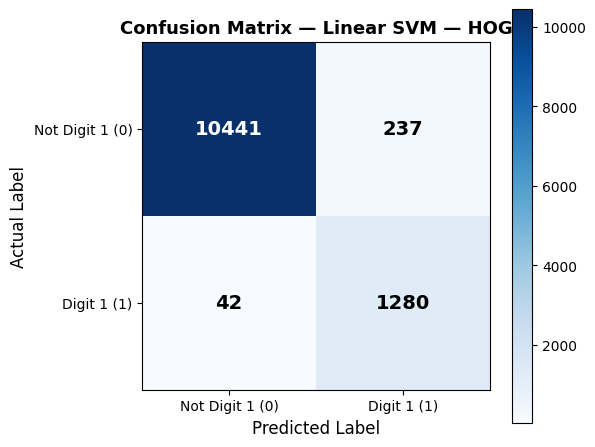

 Classification Report — Linear SVM — PCA
  Accuracy  : 0.9384  (93.84%)
  Precision : 0.9966
  Recall    : 0.4425
  F1-Score  : 0.6129
--------------------------------------------------
  TP : 585  |  FP : 2
  FN : 737  |  TN : 10676


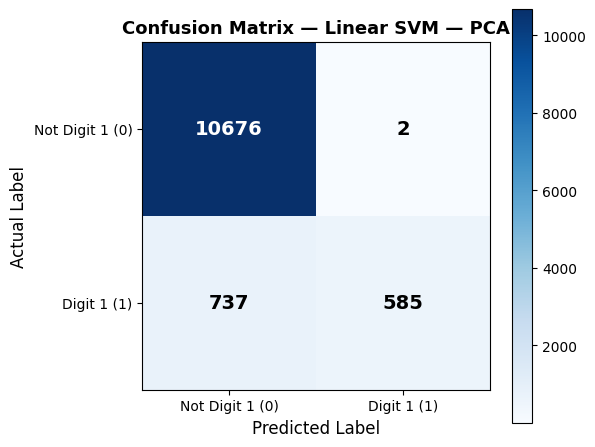

 Classification Report — Kernel SVM (Polynomial) — HOG
  Accuracy  : 0.9748  (97.47%)
  Precision : 0.9713
  Recall    : 0.7943
  F1-Score  : 0.8739
--------------------------------------------------
  TP : 1050  |  FP : 31
  FN : 272  |  TN : 10647


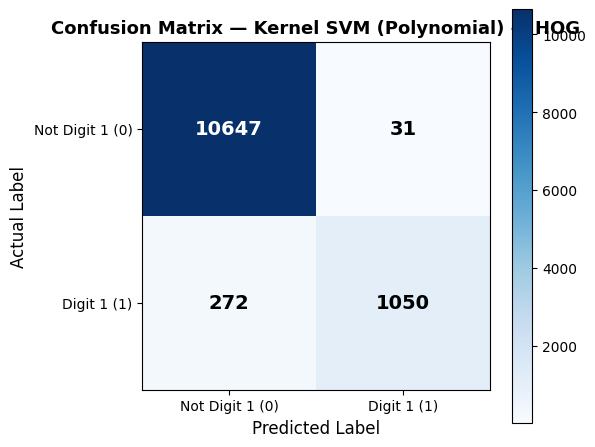

 Classification Report — Kernel SVM (Polynomial) — PCA
  Accuracy  : 0.9709  (97.09%)
  Precision : 0.9793
  Recall    : 0.7519
  F1-Score  : 0.8507
--------------------------------------------------
  TP : 994  |  FP : 21
  FN : 328  |  TN : 10657


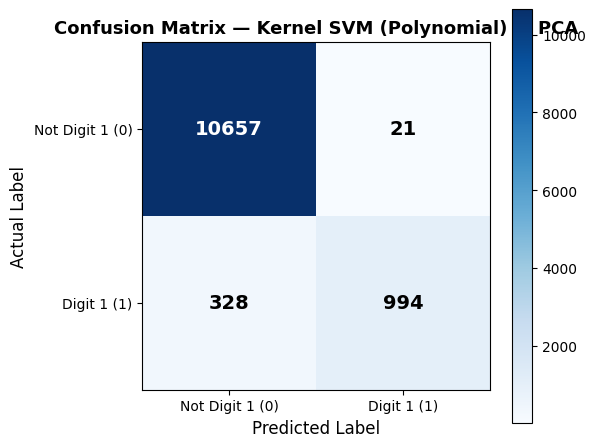

In [ ]:
# Evaluate all models on validation set

print("Evaluating all models on validation set...\n")

models = {
    "Linear SVM — HOG": (svm_linear_hog, X_val_hog),
    "Linear SVM — PCA": (svm_linear_pca, X_val_pca),
    "Kernel SVM (Polynomial) — HOG": (svm_poly_hog, X_val_hog),
    "Kernel SVM (Polynomial) — PCA": (svm_poly_pca, X_val_pca),
}

all_results = []

for name, (model, X_val) in models.items():
    y_pred = model.predict(X_val)
    result = imported_metrics.evaluate(y_val, y_pred, name)
    all_results.append(result)

## Step 8: Models Comparison
> Comparing all 4 models on the validation set.
> This helps us identify the best model and feature combination.

In [ ]:
# Print comparison table
print("="*70)
print(f"{'Model':<35} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("="*70)
for r in all_results:
    print(f"{r['model']:<35} {r['accuracy']:>10.4f} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1_score']:>10.4f}")
print("="*70)

# Find best model
best = max(all_results, key=lambda x: x['f1_score'])
print(f"\nBest Model : {best['model']}")
print(f"F1-Score   : {best['f1_score']:.4f}")
print(f"Accuracy   : {best['accuracy']:.4f}")

Model                                 Accuracy  Precision     Recall         F1
Linear SVM — HOG                        0.9768     0.8438     0.9682     0.9017
Linear SVM — PCA                        0.9384     0.9966     0.4425     0.6129
Kernel SVM (Polynomial) — HOG           0.9748     0.9713     0.7943     0.8739
Kernel SVM (Polynomial) — PCA           0.9709     0.9793     0.7519     0.8507

Best Model : Linear SVM — HOG
F1-Score   : 0.9017
Accuracy   : 0.9768


## Step 9: Final Evaluation on Test Set
> We evaluate the best model (Linear SVM — HOG) on the test set.
> The test set has never been seen during training or validation.
> This gives us the final unbiased performance of our model.

**Why test set evaluation is important:**
> Validation set was used to compare models and select the best one.
> This means validation results may be slightly optimistic.
> Test set gives a true unbiased estimate of real-world performance.

Final Evaluation on Test Set
Best Model: Linear SVM — HOG
 Classification Report — Linear SVM — HOG (Test Set)
  Accuracy  : 0.9836  (98.36%)
  Precision : 0.8918
  Recall    : 0.9736
  F1-Score  : 0.9309
--------------------------------------------------
  TP : 1105  |  FP : 134
  FN : 30  |  TN : 8731


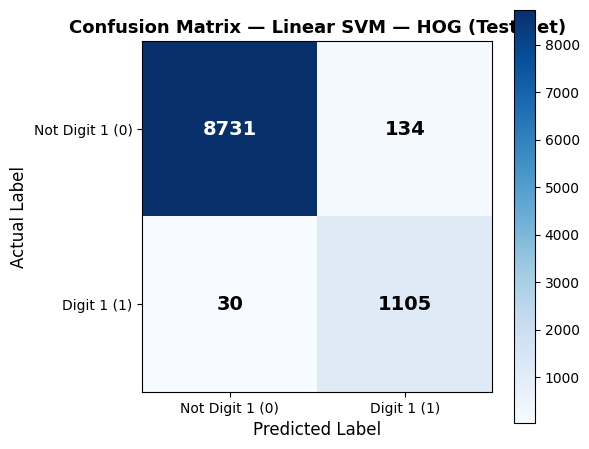

In [ ]:
# Final evaluation on test set using best model
print("Final Evaluation on Test Set")
print("Best Model: Linear SVM — HOG")
print("="*50)

y_pred_test = svm_linear_hog.predict(X_test_hog)
final_results = imported_metrics.evaluate(y_test, y_pred_test, "Linear SVM — HOG (Test Set)")

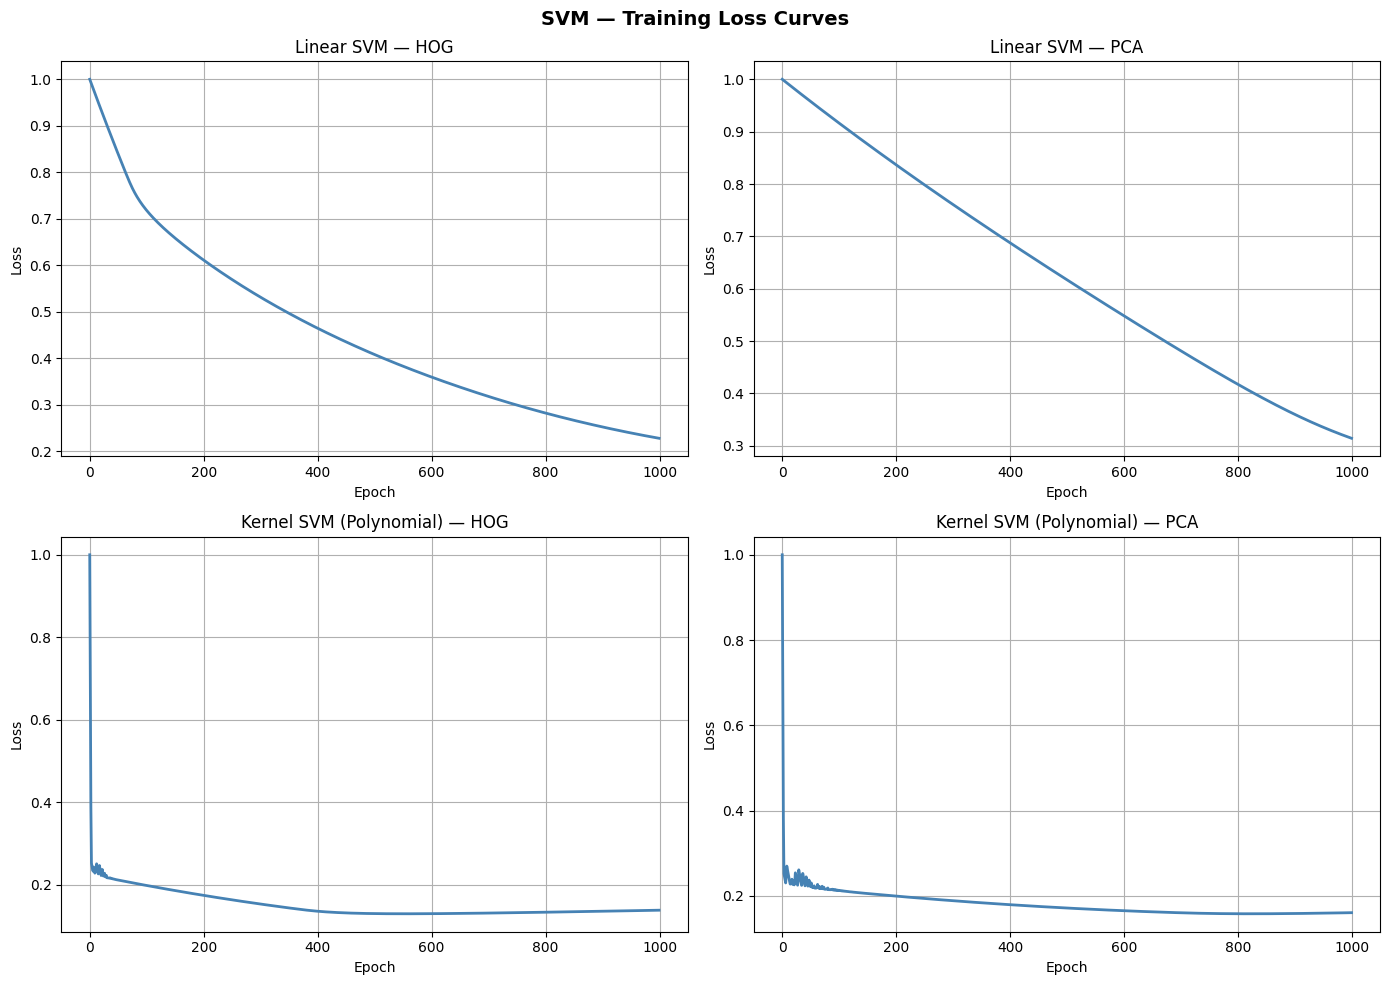

✅ Loss curves saved!


In [ ]:
import os
os.makedirs('/content/MNIST-ML-ImageClassifiers/results', exist_ok=True)

# Save loss curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(svm_linear_hog.loss_history, color='steelblue', linewidth=2)
axes[0,0].set_title('Linear SVM — HOG')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].grid(True)

axes[0,1].plot(svm_linear_pca.loss_history, color='steelblue', linewidth=2)
axes[0,1].set_title('Linear SVM — PCA')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].grid(True)

axes[1,0].plot(svm_poly_hog.loss_history, color='steelblue', linewidth=2)
axes[1,0].set_title('Kernel SVM (Polynomial) — HOG')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].grid(True)

axes[1,1].plot(svm_poly_pca.loss_history, color='steelblue', linewidth=2)
axes[1,1].set_title('Kernel SVM (Polynomial) — PCA')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Loss')
axes[1,1].grid(True)

plt.suptitle('SVM — Training Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/MNIST-ML-ImageClassifiers/results/svm_loss_curves.png', dpi=150)
plt.show()
print(" Loss curves saved!")

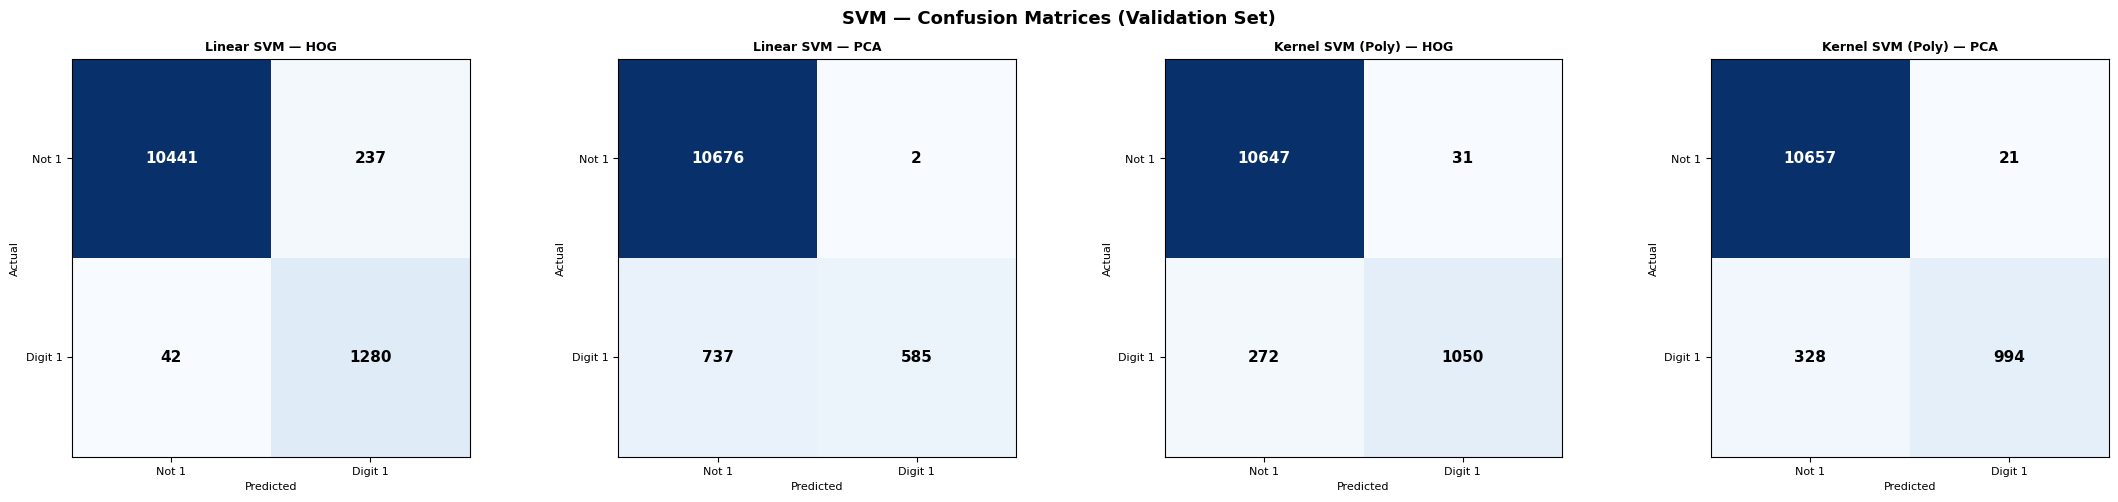

✅ Confusion matrices saved!


In [ ]:
# Save all confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

models_eval = [
    ("Linear SVM — HOG",            svm_linear_hog, X_val_hog),
    ("Linear SVM — PCA",            svm_linear_pca, X_val_pca),
    ("Kernel SVM (Poly) — HOG",     svm_poly_hog,   X_val_hog),
    ("Kernel SVM (Poly) — PCA",     svm_poly_pca,   X_val_pca),
]

for idx, (name, model, X_val) in enumerate(models_eval):
    y_pred = model.predict(X_val)

    # Compute confusion matrix
    TP = int(np.sum((y_pred == 1) & (y_val == 1)))
    TN = int(np.sum((y_pred == 0) & (y_val == 0)))
    FP = int(np.sum((y_pred == 1) & (y_val == 0)))
    FN = int(np.sum((y_pred == 0) & (y_val == 1)))
    cm = np.array([[TN, FP], [FN, TP]])

    im = axes[idx].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(name, fontsize=9, fontweight='bold')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['Not 1', 'Digit 1'], fontsize=8)
    axes[idx].set_yticklabels(['Not 1', 'Digit 1'], fontsize=8)
    axes[idx].set_xlabel('Predicted', fontsize=8)
    axes[idx].set_ylabel('Actual', fontsize=8)

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            axes[idx].text(j, i, format(cm[i, j], 'd'),
                          ha="center", va="center",
                          color="white" if cm[i, j] > thresh else "black",
                          fontsize=11, fontweight='bold')

plt.suptitle('SVM — Confusion Matrices (Validation Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/MNIST-ML-ImageClassifiers/results/svm_confusion_matrices.png', dpi=150)
plt.show()
print("Confusion matrices saved!")

In [ ]:
# Save results table as CSV manually
csv_content = "Model,Accuracy,Precision,Recall,F1-Score\n"
for r in all_results:
    csv_content += f"{r['model']},{r['accuracy']:.4f},{r['precision']:.4f},{r['recall']:.4f},{r['f1_score']:.4f}\n"

# Add test set results
csv_content += f"Linear SVM — HOG (Test Set),{final_results['accuracy']:.4f},{final_results['precision']:.4f},{final_results['recall']:.4f},{final_results['f1_score']:.4f}\n"

with open('/content/MNIST-ML-ImageClassifiers/results/svm_results.csv', 'w') as f:
    f.write(csv_content)

print(" Results table saved!")
print("\nResults:")
print(csv_content)

✅ Results table saved!

Results:
Model,Accuracy,Precision,Recall,F1-Score
Linear SVM — HOG,0.9768,0.8438,0.9682,0.9017
Linear SVM — PCA,0.9384,0.9966,0.4425,0.6129
Kernel SVM (Polynomial) — HOG,0.9748,0.9713,0.7943,0.8739
Kernel SVM (Polynomial) — PCA,0.9709,0.9793,0.7519,0.8507
Linear SVM — HOG (Test Set),0.9836,0.8918,0.9736,0.9309

